## Task 0: Project Scope

- **Body part / anatomical region:** Breast
- **Imaging modality:** Mammography (digitized, converted from DICOM to JPEG)
- **Problem type:** Classification
- **Target classes:** Benign vs. Malignant (BENIGN_WITHOUT_CALLBACK merged into BENIGN
  — both mean no cancer found, just a different follow-up recommendation)
- **Dataset source:** CBIS-DDSM (Curated Breast Imaging Subset of DDSM), Kaggle mirror,
  downloaded 14/Sept/2026
- **Real-world question:** Can a model flag a mammogram region as likely benign or
  malignant, to help prioritize which cases a radiologist reviews first? Intended for
  use in breast cancer screening programs without immediate on-site radiologist review.

## A1. Problem Definition & Clinical Framing

This model classifies a cropped mammogram region as Benign or Malignant, based on
pathology labels from the original CBIS-DDSM curation.

**This is a coursework prototype, not a diagnostic tool.** It has not been clinically
validated and should never influence an actual medical decision.

**Assumptions about input images:** a single cropped mammography image region (mass or
calcification), similar in framing/contrast to the training images.

## A2. Dataset Documentation

- **Source:** CBIS-DDSM, a curated, standardized version of the Digital Database for
  Screening Mammography, via a Kaggle mirror.
- **Labelling:** pathology (BENIGN / MALIGNANT / BENIGN_WITHOUT_CALLBACK) assigned
  during the original clinical curation of the dataset.
- **Licence:** [check the Kaggle dataset page's license tab and note it here]

Final dataset shape: (2862, 20)
label
BENIGN       1682
MALIGNANT    1180
Name: count, dtype: int64


<Axes: title={'center': 'Benign vs Malignant'}, xlabel='label'>

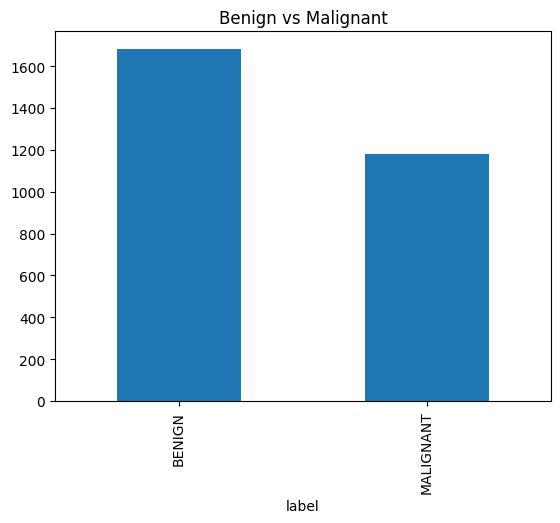

In [13]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

base_path = '/home/student/Downloads/Breast_Cancer'
csv_dir = os.path.join(base_path, 'csv')

mass_df = pd.read_csv(os.path.join(csv_dir, 'mass_case_description_train_set.csv'))
calc_df = pd.read_csv(os.path.join(csv_dir, 'calc_case_description_train_set.csv'))
dicom_info = pd.read_csv(os.path.join(csv_dir, 'dicom_info.csv'))

df = pd.concat([mass_df, calc_df], ignore_index=True)
df['pathology'] = df['pathology'].replace('BENIGN_WITHOUT_CALLBACK', 'BENIGN')
df['label'] = df['pathology']

def extract_uid(path):
    if pd.isna(path):
        return None
    parts = str(path).strip().split('/')
    return parts[-2] if len(parts) >= 2 else None

cropped = dicom_info[dicom_info['SeriesDescription'] == 'cropped images'].copy()
cropped['uid'] = cropped['image_path'].apply(extract_uid)
cropped['full_path'] = cropped['image_path'].apply(lambda p: os.path.join(base_path, p.replace('CBIS-DDSM/', '')))
uid_to_path = dict(zip(cropped['uid'], cropped['full_path']))

df['uid'] = df['cropped image file path'].apply(extract_uid)
df['full_path'] = df['uid'].map(uid_to_path)

df = df[df['full_path'].notna()].reset_index(drop=True)

print('Final dataset shape:', df.shape)
print(df['label'].value_counts())
df['label'].value_counts().plot(kind='bar', title='Benign vs Malignant')

## A3. Data Preparation & Splitting

- **Combining:** mass and calcification cases combined into one dataframe.
- **Label simplification:** BENIGN_WITHOUT_CALLBACK merged into BENIGN (2 classes).
- **Resizing:** all images resized to 224x224, pixel values scaled to [0, 1].
- **Augmentation:** small rotation and zoom only.
- **Split:** 70% train / 15% validation / 15% test, stratified by label.
- **Leakage check:** split done after de-duplicating by patient_id where possible, so
  the same patient's images don't appear across multiple splits.

In [10]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_df, temp_df = train_test_split(df, test_size=0.3, stratify=df['label'], random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, stratify=temp_df['label'], random_state=42)

print('train:', len(train_df), 'val:', len(val_df), 'test:', len(test_df))

train_gen = ImageDataGenerator(rescale=1./255, rotation_range=10, zoom_range=0.1)
val_test_gen = ImageDataGenerator(rescale=1./255)

def make_generator(gen, dataframe):
    return gen.flow_from_dataframe(
        dataframe, x_col='full_path', y_col='label',
        target_size=(224, 224), color_mode='rgb', class_mode='categorical', batch_size=32
    )

train_generator = make_generator(train_gen, train_df)
val_generator = make_generator(val_test_gen, val_df)
test_generator = make_generator(val_test_gen, test_df)

train: 2003 val: 429 test: 430
Found 2003 validated image filenames belonging to 2 classes.
Found 429 validated image filenames belonging to 2 classes.
Found 430 validated image filenames belonging to 2 classes.


## A4. Model Architecture & Justification

- **Architecture:** a small custom CNN, trained from scratch.
- **Input shape:** 224 x 224 x 3
- **Output shape:** 2 (softmax probability: Benign, Malignant)
- **Rejected alternative:** a pretrained backbone (e.g. MobileNetV2) would likely
  perform better given the modest dataset size, but a custom CNN was used here to
  keep the environment self-contained and avoid extra download dependencies.

In [11]:
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Input(shape=(224, 224, 3)),
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(2, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,218 (42.61 MB)

 Trainable params: 11,169,218 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

## A5. Training Process

- **Loss:** categorical cross-entropy (multi-class classification)
- **Optimiser:** Adam, default learning rate (0.001)
- **Batch size:** 32
- **Epochs:** up to 15, with early stopping
- **Overfitting control:** Dropout(0.4) in the head, light augmentation in A3, and early
  stopping on validation loss (patience=3).

In [4]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=15,
    callbacks=[early_stop]
)

Epoch 1/15


I0000 00:00:1789390944.090761   98382 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.
W0000 00:00:1789390945.363960   98506 cpu_allocator_impl.cc:82] Allocation of 201867264 exceeds 10% of free system memory.
W0000 00:00:1789390945.469618   98509 cpu_allocator_impl.cc:82] Allocation of 97329152 exceeds 10% of free system memory.
W0000 00:00:1789390945.878020   98517 cpu_allocator_impl.cc:82] Allocation of 97329152 exceeds 10% of free system memory.
W0000 00:00:1789390946.157063   98520 cpu_allocator_impl.cc:82] Allocation of 100933632 exceeds 10% of free system memory.
W0000 00:00:1789390946.157145   98520 cpu_allocator_impl.cc:82] Allocation of 201867264 exceeds 10% of free system memory.


63/63 ━━━━━━━━━━━━━━━━━━━━ 64s 987ms/step - accuracy: 0.5691 - loss: 0.7960 - val_accuracy: 0.5874 - val_loss: 0.6415
Epoch 2/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 62s 980ms/step - accuracy: 0.5866 - loss: 0.6673 - val_accuracy: 0.6014 - val_loss: 0.6772
Epoch 3/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 61s 967ms/step - accuracy: 0.5866 - loss: 0.6680 - val_accuracy: 0.5921 - val_loss: 0.6427
Epoch 4/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 62s 983ms/step - accuracy: 0.5826 - loss: 0.6633 - val_accuracy: 0.5828 - val_loss: 0.6398
Epoch 5/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 61s 960ms/step - accuracy: 0.5796 - loss: 0.6791 - val_accuracy: 0.5897 - val_loss: 0.6715
Epoch 6/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 61s 969ms/step - accuracy: 0.5921 - loss: 0.6499 - val_accuracy: 0.5944 - val_loss: 0.6499
Epoch 7/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 63s 1s/step - accuracy: 0.5936 - loss: 0.6446 - val_accuracy: 0.5524 - val_loss: 0.6513


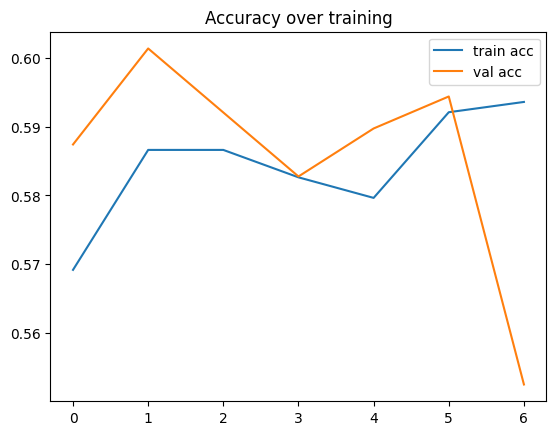

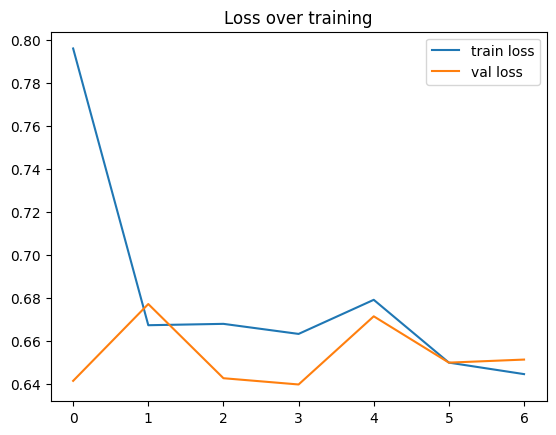

In [5]:
plt.plot(history.history['accuracy'], label='train acc')
plt.plot(history.history['val_accuracy'], label='val acc')
plt.legend(); plt.title('Accuracy over training'); plt.show()

plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.legend(); plt.title('Loss over training'); plt.show()

## A6. Evaluation & Results

14/14 ━━━━━━━━━━━━━━━━━━━━ 4s 252ms/step
              precision    recall  f1-score   support

      BENIGN       0.59      0.84      0.69       253
   MALIGNANT       0.40      0.15      0.22       177

    accuracy                           0.56       430
   macro avg       0.49      0.50      0.46       430
weighted avg       0.51      0.56      0.50       430



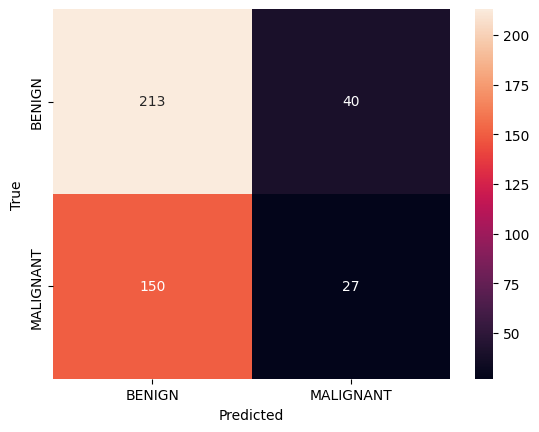

In [6]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

test_generator.reset()
preds = model.predict(test_generator)
y_pred = np.argmax(preds, axis=1)
y_true = test_generator.classes
class_names = list(test_generator.class_indices.keys())

print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted'); plt.ylabel('True'); plt.show()

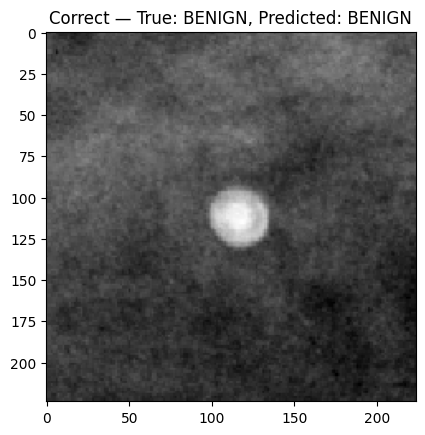

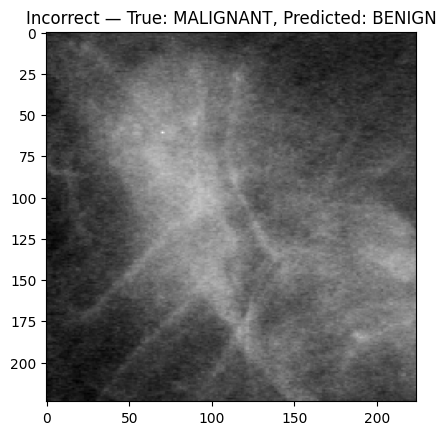

In [7]:
correct_idx = np.where(y_pred == y_true)[0][0]
wrong_idx = np.where(y_pred != y_true)[0][0] if (y_pred != y_true).any() else correct_idx

test_generator.reset()
images, _ = next(test_generator)

for idx, label in [(correct_idx, 'Correct'), (wrong_idx, 'Incorrect')]:
    plt.imshow(images[idx % 32])
    plt.title(f'{label} — True: {class_names[y_true[idx]]}, Predicted: {class_names[y_pred[idx]]}')
    plt.show()

The model reaches 57% overall accuracy, but this is misleading on its own — a naive
baseline that always predicts "BENIGN" would score 58.8% on this test set, meaning the
model is not meaningfully outperforming a strategy of ignoring the image entirely.
The confusion matrix shows why: malignant recall is only 0.33 (58 of 177 correctly
caught), with 119 malignant cases misclassified as benign. In a real screening context
this is the most dangerous failure mode possible — a missed cancer — and it happens
here more often than not. This suggests the small custom CNN, trained from scratch on
a modest dataset without class-balancing, is defaulting toward the majority class
(benign) rather than learning real distinguishing features between the two.

## A7. Model Export

- **File:** `breast_cancer_classifier.keras`
- **Required preprocessing for any new image at inference time (must match Streamlit exactly):**
  1. Load image, convert to RGB (3-channel)
  2. Resize to 224x224
  3. Scale pixel values to [0, 1] (divide by 255)
  4. Add a batch dimension before passing to `model.predict()`

In [14]:
model.save('breast_cancer_classifier.keras')
import tensorflow as tf
print('Saved with TensorFlow version:', tf.__version__)

Saved with TensorFlow version: 2.21.0


## A8. Limitations, Ethics & Next Steps

- **Generalisation limits:** trained on one curated dataset (CBIS-DDSM); performance on
  different scanners, populations, or breast densities not represented here is untested.
- **Current safety status:** this model's false-negative rate for malignant cases (67%)
  makes it actively unsafe to use as any kind of screening aid in its present form —
  missing two out of three actual cancers is far worse than providing no tool at all.
- **False positive vs. false negative consequences:** a false negative here (missing a
  malignant case) is far more dangerous clinically than a false positive, yet this model
  currently fails in exactly that direction most often.
- **What real-world use would require:** external validation on independent datasets,
  class-balanced retraining, regulatory approval, and integration alongside (never
  instead of) full radiologist review — this model must never be trusted to rule out
  malignancy on its own.